# Fairness : Mi-Projet

*Travail réalisé par Cyprien BRION - L3 Informatique*

## Introduction

L'essor des méthodes d'apprentissage automatique dans le domaine médical soulève des enjeux majeurs en matière d'équité et de biais algorithmiques. En effet, les modèles entraînés sur des données de santé peuvent reproduire, voire amplifier, des biais présents dans les jeux de données d'origine, liés par exemple à l'âge, au genre ou à d'autres caractéristiques démographiques des patients. Ces biais peuvent donc conduire à des performances inégales selon les populations et poser de nombreux problèmes éthiques.

Dans ce mi-projet, nous nous intéresserons au jeu de données NIH Chest X-ray 14, qui regroupe des examens de radiographies thoraciques accompagnés de métadonnées décrivant les patients. Dans un premier temps, nous nous concentrerons exclusivement sur ces métadonnées, sans exploiter les images, afin d'analyser la structure du jeu de données et d'identifier d'éventuels biais statistiques.

Dans ce notebook, nous réaliserons une analyse descriptive approfondie des métadonnées afin de mettre en évidence des biais potentiels entre différents groupes d'individus. Ensuite, nous réaliserons une méthode de mitigation des biais par pré-processing visant à atténuer ces biais, tout en conservant autant que possible l'information utile contenue dans les données.

## I. Préparation de la donnée

### a. Chargement de données et aperçu des données

Commençons par charger notre jeu de données :

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Pour le chargement du jeu de données
df = pd.read_csv("Brion_Cyprien.csv")
df.head()


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
0,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171
1,00000004_000.png,Mass|Nodule,0,4,82,M,AP,2500,2048,0.168,0.168
2,00000005_000.png,No Finding,0,5,69,F,PA,2048,2500,0.168,0.168
3,00000005_001.png,No Finding,1,5,69,F,AP,2500,2048,0.168,0.168
4,00000005_002.png,No Finding,2,5,69,F,AP,2500,2048,0.168,0.168


Ensuite, observons plus en détail les caractéristiques de ce jeu de données :

In [4]:
df.shape

(53951, 11)

Analysons désormais le type des variables contenues dans ce dataset :

In [5]:
df.dtypes

Image Index                     object
Finding Labels                  object
Follow-up #                      int64
Patient ID                       int64
Patient Age                      int64
Patient Gender                  object
View Position                   object
OriginalImage[Width              int64
Height]                          int64
OriginalImagePixelSpacing[x    float64
y]                             float64
dtype: object

### b. Vérifications et nettoyage du jeu de données

Vérifions désormais la présence de valeurs manquantes dans le jeu de données.

In [6]:
df.isna().sum()

Image Index                    0
Finding Labels                 0
Follow-up #                    0
Patient ID                     0
Patient Age                    0
Patient Gender                 0
View Position                  0
OriginalImage[Width            0
Height]                        0
OriginalImagePixelSpacing[x    0
y]                             0
dtype: int64

On observe qu'aucune des variables du jeu de données ne contient de valeurs manquantes.

Regardons désormais si notre jeu de données contient des valeurs aberrantes. Bien sûr, cela ne concerne que les variables numériques.

In [7]:
df.describe()

,Follow-up #,Patient ID,Patient Age,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
count,53951.000000,53951.000000,53951.000000,53951.000000,53951.000000,53951.000000,53951.000000
mean,8.432263,14409.935367,46.937054,2645.894163,2488.074790,0.155670,0.155670
std,15.228100,8371.393985,16.712377,341.299413,402.836045,0.016239,0.016239
min,0.000000,2.000000,1.000000,1143.000000,1001.000000,0.115000,0.115000
25%,0.000000,7526.000000,35.000000,2500.000000,2048.000000,0.143000,0.143000
50%,3.000000,14006.000000,49.000000,2520.000000,2544.000000,0.143000,0.143000
75%,9.000000,20725.000000,59.000000,2992.000000,2991.000000,0.168000,0.168000
max,172.000000,30805.000000,413.000000,3550.000000,4715.000000,0.198800,0.198800


On remarque ici qu'il y a des valeurs aberrantes pour la colonne `Patient Age`. En effet, le maximum pour cette colonne est de 413, ce qui signifierait qu'un patient à 413 ans, ce qui n'est clairement pas réaliste.

Pour corriger ce problème, nous allons filtrer les valeurs de la colonne `Patient Age` selon un intervalle réaliste : 

In [8]:
df = df[(df["Patient Age"] >= 0) & (df["Patient Age"] <= 120)]
df["Patient Age"].describe()

count    53942.000000
mean        46.900467
std         16.385627
min          1.000000
25%         35.000000
50%         49.000000
75%         59.000000
max         94.000000
Name: Patient Age, dtype: float64

Après nettoyage, les valeurs sont désormais bien plus réalistes.

Effectuons une analyse pour observer le nombre de valeurs distinctes par variable afin de confirmer qu'il n'y aurait pas de valeurs manquantes encodées de manière implicite.

In [9]:
df.nunique()

Image Index                    53942
Finding Labels                   627
Follow-up #                      173
Patient ID                     15000
Patient Age                       94
Patient Gender                     2
View Position                      2
OriginalImage[Width              756
Height]                          912
OriginalImagePixelSpacing[x       21
y]                                21
dtype: int64

On remarque donc que le nombre de valeurs distinctes est cohérent avec l'énoncé. Aucune variable ne présente donc de valeurs manquantes qui auraient pu être encodées implicitement.
Néanmoins, à partir de ces résultats on peut noter que :
* Les variables `Patient Gender` et `View Position` ne possèdent que deux valeurs distinctes chacune, ce qui en fait des variables clés pour l'analyse des biais.

Pour finir, vérifions si des lignes ont été dupliquées :

In [10]:
dup_rows = df.duplicated().sum()
print(f"Doublons exacts (toutes colonnes) : {dup_rows}")

Doublons exacts (toutes colonnes) : 0


Il n'y a donc aucun doublon dans notre dataset.

Pour faciliter l'analyse, nous allons transformer la variable continue `Patient Age` en catégories interprétables. Pour cela, nous allons utiliser des tranches d'âge.

In [11]:
df["age_bin"] = pd.cut(
    df["Patient Age"],
    # Remarque : on commence à 1 car l'âge minimal est 1 dans le dataset.
    bins=[1, 18, 30, 45, 60, 75, 120],
    include_lowest=True
)
df["age_bin"].value_counts().sort_index()

age_bin
(0.999, 18.0]     2824
(18.0, 30.0]      7286
(30.0, 45.0]     12560
(45.0, 60.0]     19768
(60.0, 75.0]     10313
(75.0, 120.0]     1191
Name: count, dtype: int64

De même, afin de pouvoir utiliser les métriques de fairness, nous allons effectuer un encodage binaire (`gender_bin`) du genre :

In [42]:
df["gender_bin"] = (df["Patient Gender"] == "M").astype(int)


**Remarque :** on a fixé ici arbitrairement la convention suivante pour les valeurs de `gender_bin` : 1 correspond aux individus de sexe masculin et 0 les individus de sexe féminin.

On effectue le même traitement pour l'attribut `View Position` toujours en vue de l'utilisation des métriques de fairness. On nommera `view_bin` la colonne contenant cet encodage.

In [44]:
df["view_bin"] = (df["View Position"] == "PA").astype(int)

**Remarque :** on a fixé ici arbitrairement la convention suivante pour les valeurs de `view_bin` : 1 pour PA et 0 pour AP.

Afin d’étudier l’effet du suivi, nous construisons une variable binaire `low_follow_bin` qui indique si un patient
appartient aux groupes suivants :
* “faible suivi” (≤ 3 examens dans notre sous-ensemble)
* “suivi élevé” (> 3).

Nous utiliserons `nb_exams` pour mesurer cette intensité de suivi car c’est l’indicateur le plus direct de “patients qui reviennent souvent”
dans notre dataset. En effet, il compte réellement le nombre d’examens disponibles par patient. À l’inverse, `Follow-up #` est un
indice associé à chaque examen et peut être élevé même si peu d’examens sont présents dans le sous-ensemble. Ainsi, il décrit plutôt la profondeur du suivi et semble être moins direct que `nb_exams`


In [47]:
# 1 = faible niveau de suivi (peu d'examens), 0 = suivi élevé
df["low_follow_bin"] = (df["nb_exams"] <= 3).astype(int)

Observons la distribution du nombre d'examens par patient afin de repérer les patients multi-examens :

In [12]:
exam_stats = df.groupby("Patient ID").size().describe()
print("Statistiques du nombre d'examens par patient :")
print(exam_stats)

Statistiques du nombre d'examens par patient :
count    15000.000000
mean         3.596133
std          7.163112
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        173.000000
dtype: float64


Ceci va nous permettre de répondre à la question suivante : les patients qui ont beaucoup d'examens sont-ils plus souvent malades ?

In [13]:
exam_counts = df.groupby("Patient ID").size()
exam_counts.describe()

count    15000.000000
mean         3.596133
std          7.163112
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        173.000000
dtype: float64

On découpe les patients selon leur nombre d'examens et on calcule pour chaque groupe, la proportion de patiens ayant au moins une pathologie avec `has_disease = True`

In [14]:
df = df.merge(
    exam_counts.rename("nb_exams"),
    left_on="Patient ID",
    right_index=True
)


In [15]:
df["has_disease"] = df["Finding Labels"] != "No Finding"

In [16]:
df.groupby(
    pd.cut(df["nb_exams"], bins=[0,1,3,10,200])
)["has_disease"].mean()


/tmp/ipykernel_2540/1971727585.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


nb_exams
(0, 1]       0.272535
(1, 3]       0.353521
(3, 10]      0.434452
(10, 200]    0.579562
Name: has_disease, dtype: float64

On observe une relation strictement croissante ce qui est plutôt logique. Les patients qui reviennent souvent sont beaucoup plus souvent malades. Le nombre d'examens est donc corrélé à l'état de santé.

**Remarque :** cette analyse n'est pas un biais du modèle mais cela pourra être problématique pour l'apprentissage du modèle. Nous n'irons pas plus loin pour cette analyse puisque l'apprentissage du modèle n'est pas demandé.

## II. Analyse descriptive et observation des biais

### a. Analyse univariée

#### 1. Genre (déséquilibre de représentation)

Commençons par observer la répartition des examens selon le genre :

In [17]:
gender_counts = df["Patient Gender"].value_counts()
gender_counts

Patient Gender
M    30332
F    23610
Name: count, dtype: int64

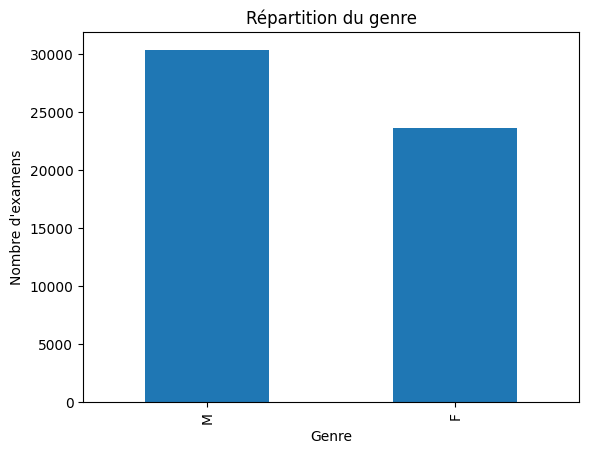

In [18]:
ax = gender_counts.plot(kind="bar")
ax.set_title("Répartition du genre")
ax.set_xlabel("Genre")
ax.set_ylabel("Nombre d'examens")
plt.show()


La répartition des examens selon le genre montre un léger déséquilibre. En effet, les hommes sont légèrement plus représentés que les femmes.
On notera cependant que l'on devra compléter cette observation par une analyse au niveau du patient car un petit nombre de patients très suivis peuvent amplifier artificiellement ce dédéquilibre.
On regardera également dans la suite la prévalence des pathologies conditionnellement au genre.

#### 2. View Position (AP/PA)

Intéressons nous désormais à l'attribut `View Position`. En effet AP/PA peut refléter des conditions d'acquisition différentes. Cela peut donc être corrélé à la maladie.

In [19]:
view_counts = df["View Position"].value_counts()
view_counts

View Position
PA    32642
AP    21300
Name: count, dtype: int64

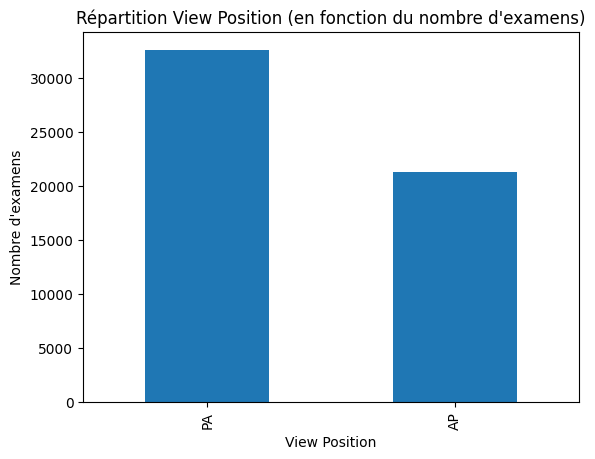

In [20]:
ax = view_counts.plot(kind="bar")
ax.set_title("Répartition View Position (en fonction du nombre d'examens)")
ax.set_xlabel("View Position")
ax.set_ylabel("Nombre d'examens")
plt.show()


La répartition de la variable `View Position` montre un déséquilibre : les examens en position PA sont plus nombreux que ceux en position AP.
On notera que cette variable est particulièrement importante car AP et PA peuvent refléter des conditions d'acquisition différentes (patients debout vs allongés / urgence) et donc être corrélés à la présence de pathologies. Dans la suite, nous analyserons la prévalence des pathologies conditionnellement à `View Position` et nous quantifierons cet écart.

#### 3. Distribution globale de l'âge

Naturellement, l'âge est un facteur médical majeur : une surreprésentation des séniors (ou l'inverse) peut conduire à des distributions de maladies très différentes entre groupes.

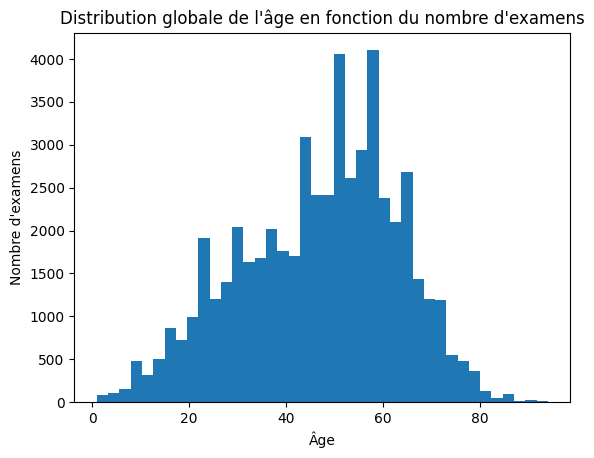

In [21]:
plt.figure()
plt.hist(df["Patient Age"], bins=40)
plt.title("Distribution globale de l'âge en fonction du nombre d'examens")
plt.xlabel("Âge")
plt.ylabel("Nombre d'examens")
plt.show()


La distribution globale de l'âge paraît cohérente : la majorité des examens concernent des adultes, avec un pic autour de 50–60 ans, puis une décroissance pour les âges élevés. Les extrêmes d'âge ne sont que très peu représentés. Néanmoins ceci paraît plutôt normal puisque les pathologies thoraciques sont globalement plus fréquentes à certains âges. Il est donc logique que les adultes dans la tranche 50-60 ans soient plus représentés.

#### 4. Suivi médical par patient

Observons désormais la distribution du nombre d'examens par patient :

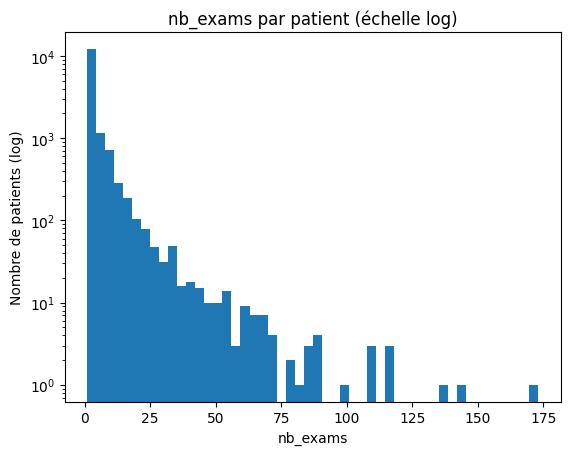

In [22]:
plt.figure()
plt.hist(exam_counts, bins=50, log=True)
plt.title("nb_exams par patient (échelle log)")
plt.xlabel("nb_exams")
plt.ylabel("Nombre de patients (log)")
plt.show()


On observe que la majorité des patients n’ont que très peu d’examens, tandis qu’une minorité possède un nombre très élevé d’examens (jusqu’à ~170).

#### 5. Prévalence globale "malade" v.s. "No Finding"

Nous évaluons désormais la prévalence globale des pathologies dans notre dataset en comparant
les examens “No Finding” aux examens présentant au moins une anomalie.

In [23]:
df["has_disease"].mean(), df["has_disease"].value_counts()


(np.float64(0.46197767973008047),
 has_disease
 False    29022
 True     24920
 Name: count, dtype: int64)

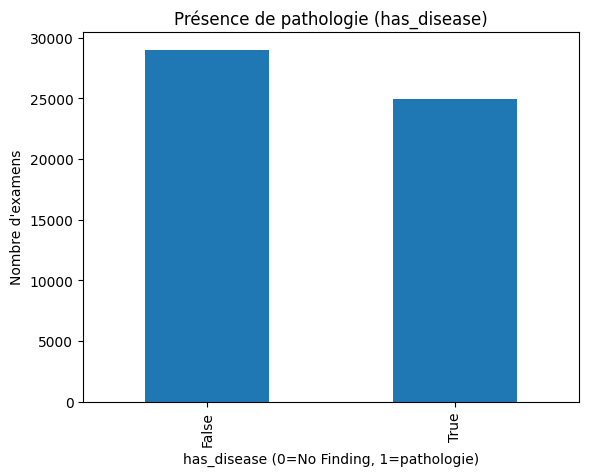

In [24]:
ax = df["has_disease"].value_counts().plot(kind="bar")
ax.set_title("Présence de pathologie (has_disease)")
ax.set_xlabel("has_disease (0=No Finding, 1=pathologie)")
ax.set_ylabel("Nombre d'examens")
plt.show()


La comparaison globale entre examens “No Finding” et examens présentant au moins une pathologie
montre un léger déséquilibre en faveur de “No Finding”. Cependant, l’écart reste modéré et la
répartition est relativement proche d’un équilibre entre les deux classes.

In [25]:
df["has_disease"].mean()

np.float64(0.46197767973008047)

La prévalence globale (i.e. la proportion d’examens dans le dataset qui sont classés “malade” (c'est à dire `has_disease = 1`), sur l’ensemble du dataset est donc ici d'environ 46%.

#### 6. Analyse multi-label : les top-pathologies (hors No Finding)

`Finding Labels` étant une variable multi-label, certaines combinaisons et pathologies rares peuvent être peu représentées lors des examens. C'est ce que l'on va tenter d'observer ici :

In [26]:
labels = df["Finding Labels"].str.split("|").explode()
labels = labels[labels != "No Finding"]
top10 = labels.value_counts().head(10)
top10

Finding Labels
Infiltration          9568
Effusion              6269
Atelectasis           5586
Nodule                3188
Mass                  2910
Pneumothorax          2342
Consolidation         2214
Pleural_Thickening    1635
Cardiomegaly          1397
Emphysema             1214
Name: count, dtype: int64

On trace un graphe pour mieux visualiser :

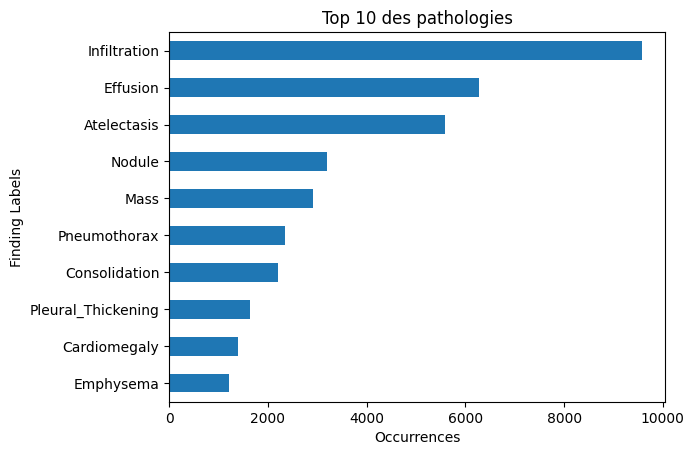

In [27]:
ax = top10.sort_values().plot(kind="barh")
ax.set_title("Top 10 des pathologies")
ax.set_xlabel("Occurrences")
plt.show()


**Remarque :** une image peut compter plusieurs occurences (si plusieurs labels) donc ici le graphe décrit une prévalence des labels par examens, pas par patient.

Ceci paraît cohérent médicalement parlant, malgré une présence majoritaire de certains labels (notamment `Infiltration` et `Effusion`). En effet, certaines anomalies sont plus communes dans les radios thoraciques que d'autres.

### b. Analyse bivariée (biais / dépendances)

#### 1. L'âge selon le genre

Observons désormais la distribution de l'âge entre les genres afin de vérifier si les groupes présentent des profils d'âge différents. En effet, l'âge influence fortement la prévalence des pathologies donc une différence de distribution pourrait agir comme facteur de confusion dans l'analyse des biais liés au genre.

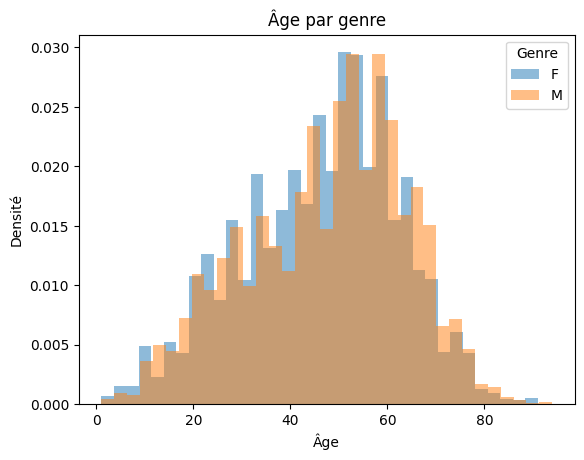

,count,mean,50%,std,min,max
Patient Gender,,,,,,
F,23610.0,46.172935,48.0,16.134081,1.0,91.0
M,30332.0,47.466768,50.0,16.556938,1.0,94.0


In [28]:
plt.figure()
for g, sub in df.groupby("Patient Gender"):
    plt.hist(sub["Patient Age"], bins=35, alpha=0.5, density=True, label=g)
plt.title("Âge par genre")
plt.xlabel("Âge")
plt.ylabel("Densité")
plt.legend(title="Genre")
plt.show()

df.groupby("Patient Gender")["Patient Age"].describe()[["count","mean","50%","std","min","max"]]


On observe donc que les deux distributions se recouvrent largement. Cela suggère donc que le genre n'est pas fortement associé à l'âge.

Traçons un diagramme en moustache pour bien résumer les distributions :

/tmp/ipykernel_2540/3210197175.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["F","M"], showfliers=False)


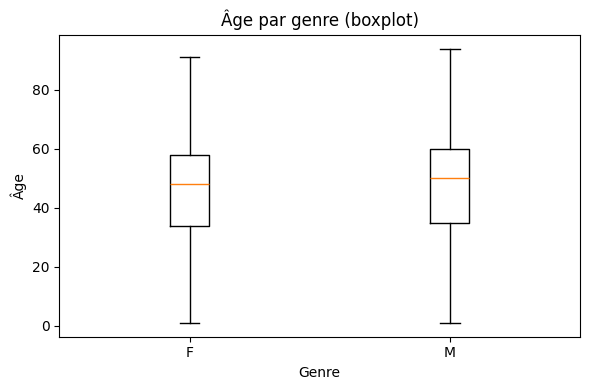

In [29]:
plt.figure(figsize=(6,4))
data = [df.loc[df["Patient Gender"]=="F", "Patient Age"],
        df.loc[df["Patient Gender"]=="M", "Patient Age"]]
plt.boxplot(data, labels=["F","M"], showfliers=False)
plt.title("Âge par genre (boxplot)")
plt.xlabel("Genre")
plt.ylabel("Âge")
plt.tight_layout()
plt.show()


Ce diagramme nous permet de confirmer et de mieux visualiser ce qui a été dit plus haut. En effet, on remarque bien que les deux genres présentent des distributions très proches : les médianes sont similaires et les dispersions sont comparables.

#### 2. Taux de pathologie selon l'âge

Intéressons-nous désormais à l'impact de l'âge sur la prévalence des pathologies, en calculant la proportion d'examens présentant au moins une anomalie (`has_disease`) pour chaque tranche d'âge.

On cherche donc à observer ici la proportion d'examens malades parmi ceux de cette tranche.

In [30]:
age_disease = df.groupby("age_bin", observed=True)["has_disease"].mean()
age_disease

age_bin
(0.999, 18.0]    0.409703
(18.0, 30.0]     0.426709
(30.0, 45.0]     0.420064
(45.0, 60.0]     0.480929
(60.0, 75.0]     0.503636
(75.0, 120.0]    0.568430
Name: has_disease, dtype: float64

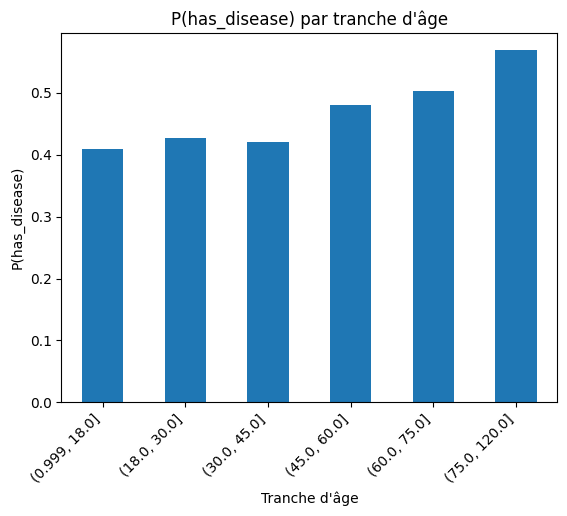

In [31]:
ax = age_disease.plot(kind="bar")
ax.set_title("P(has_disease) par tranche d'âge")
ax.set_xlabel("Tranche d'âge")
ax.set_ylabel("P(has_disease)")
plt.xticks(rotation=45, ha="right")
plt.show()

Contrairement à la partie univariée où nous avons étudié la distribution globale de l'âge, cette analyse bivariée mesure ici la prévalence des pathologies en fonction de l'âge via la probabilité conditionnelle P(has_disease | tranche d'âge).
Ceci indique que l'âge est une variable structurante du dataset. Toute différence de distribution d'âge entre les groupes (genre, View Position, niveau de suivi) peut induire des différences de prévalence de maladie, indépendemment d'un biais qui serait intrasèque au groupe.

#### 3. Taux de pathologie selon le genre

Analysons désormais si la prévalence des pathologies varie selon le genre, en comparant la proportion d’examens “No Finding” et “pathologie” (`has_disease`) pour les femmes et les hommes.


In [32]:
tab_gender = pd.crosstab(df["Patient Gender"], df["has_disease"], normalize="index")
tab_gender

has_disease,False,True
Patient Gender,,
F,0.537950,0.462050
M,0.538079,0.461921


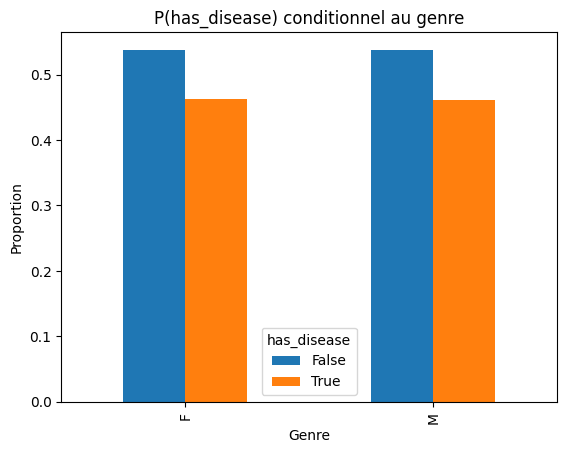

In [33]:
ax = tab_gender.plot(kind="bar")
ax.set_title("P(has_disease) conditionnel au genre")
ax.set_xlabel("Genre")
ax.set_ylabel("Proportion")
plt.legend(title="has_disease")
plt.show()

On observe clairement des proportions très similaires entre les femmes et les hommes : la part d'examens présentant une pathologie (`has_disease = True`) est quasiment identique dans les deux groupes. Cela suggère qu'il n'y a pas de biais de prévalence marqué lié au genre à ce stade de l'analyse. Nous vérifierons dans la suite, s'il existe des biais plus fins notamment par pathologie spécifique.

#### 4. Taux de pathologie selon View Position (AP/PA)

Observons désormais l'impact de `View Position` (AP / PA) sur la prévalence des pathologies. Cette analyse permettra de détecter un éventuel biais d’acquisition, car l’angle de prise de vue peut dépendre du contexte clinique.

In [34]:
tab_view = pd.crosstab(df["View Position"], df["has_disease"], normalize="index")
tab_view

has_disease,False,True
View Position,,
AP,0.477559,0.522441
PA,0.577477,0.422523


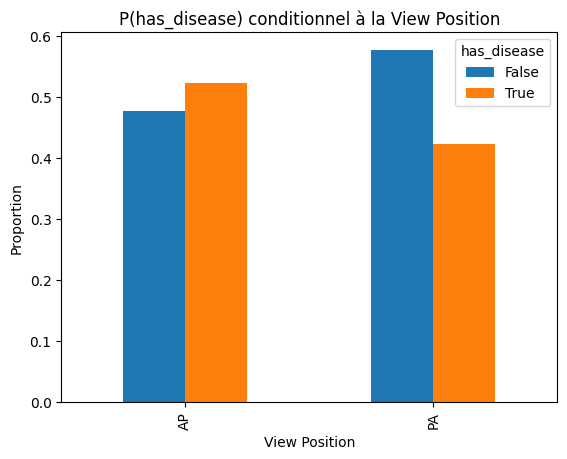

In [35]:
ax = tab_view.plot(kind="bar")
ax.set_title("P(has_disease) conditionnel à la View Position")
ax.set_xlabel("View Position")
ax.set_ylabel("Proportion")
plt.legend(title="has_disease")
plt.show()


On observe une différence marquée de prévalence selon la valeur de `View Position`. Il est clair que les examens en AP présentent une proportion de pathologies plus élevée que ceux en PA. Cela suggère un biais d'acquisition (ou un effet de contexte), la position AP pouvant être associée à des conditions cliniques particulières.

#### 5. View Position selon le genre

Nous étudions ici si la répartition des prises de vue (AP/PA) est similaire selon le genre.
Étant donné que la View Position n’est pas neutre dans notre dataset, il est important de vérifier si femmes et hommes sont observés dans des conditions d’acquisition comparables.

In [36]:
tab_view_gender = pd.crosstab(df["Patient Gender"], df["View Position"], normalize="index")
tab_view_gender

View Position,AP,PA
Patient Gender,,
F,0.383566,0.616434
M,0.403666,0.596334


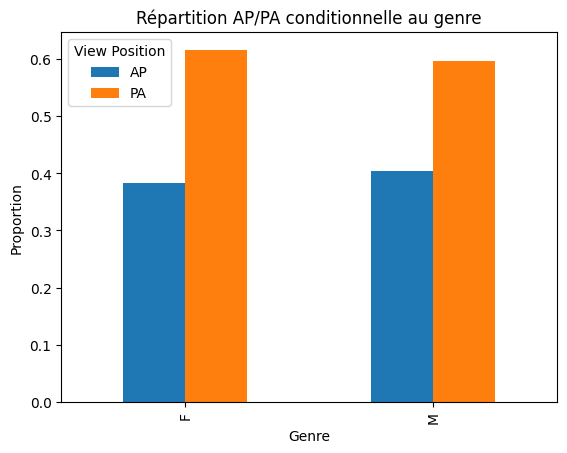

In [37]:
ax = tab_view_gender.plot(kind="bar")
ax.set_title("Répartition AP/PA conditionnelle au genre")
ax.set_xlabel("Genre")
ax.set_ylabel("Proportion")
plt.legend(title="View Position")
plt.show()

La répartition des prises de vue AP/PA est globalement similaire entre femmes et hommes même si la vue PA reste majoritaire dans les deux groupes. On observe au plus un très léger écart (les hommes semblent avoir un peu plus d’examens en AP).
Comme la prévalence d’examens pathologiques n’est pas la même entre AP et PA (nous l'avons vu en section 3.4), cette vérification était importante pour s’assurer que la comparaison entre genres repose sur des conditions d’acquisition comparables.

#### 6. Prévalence de pathologies en fonction du niveau de suivi des patients

# TODO

### c. Quantification à l'aide des métriques de fairness

Dans cette partie, nous utiliserons la fonction vue en cours `get_metrics` dont voici son implémentation :

In [40]:
from aif360.sklearn.metrics import *
from sklearn.metrics import  balanced_accuracy_score

 
# This method takes lists
def get_metrics(
    y_true, # list or np.array of truth values
    y_pred=None,  # list or np.array of predictions
    prot_attr=None, # list or np.array of protected/sensitive attribute values
    priv_group=1, # value taken by the privileged group
    pos_label=1, # value taken by the positive truth/prediction
    sample_weight=None # list or np.array of weights value,
):
    group_metrics = {}
    group_metrics["base_rate_truth"] = base_rate(
        y_true=y_true, pos_label=pos_label, sample_weight=sample_weight
    )
    group_metrics["statistical_parity_difference"] = statistical_parity_difference(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
    )
    group_metrics["disparate_impact_ratio"] = disparate_impact_ratio(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
    )
    if not y_pred is None:
        group_metrics["base_rate_preds"] = base_rate(
        y_true=y_pred, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["equal_opportunity_difference"] = equal_opportunity_difference(
            y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["average_odds_difference"] = average_odds_difference(
            y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
        )
        if len(set(y_pred))>1:
            group_metrics["conditional_demographic_disparity"] = conditional_demographic_disparity(
                y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
            )
        else:
            group_metrics["conditional_demographic_disparity"] =None
        group_metrics["smoothed_edf"] = smoothed_edf(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["df_bias_amplification"] = df_bias_amplification(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["balanced_accuracy_score"] = balanced_accuracy_score(
        y_true=y_true, y_pred=y_pred, sample_weight=sample_weight
        )
    return group_metrics

2026-01-27 22:23:00.178550: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-27 22:23:00.728370: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-27 22:23:02.403397: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/brion/Fairness/.venv/lib/python3.12/site-packages/inFairness/utils/ndcg.py:37: Future

#### 1. Mesure des écarts de prévalence de `has_disease`

Après les analyses descriptives, nous quantifions maintenant les écarts de prévalence de `has_disease` entre groupes à l’aide des métriques de fairness. L’objectif est d’obtenir une mesure chiffrée (SPD, DI) des différences observées selon le genre, la View Position et le niveau de suivi (que l'on a défini). Cette section, nous permet de confirmer et de quantifier plus précisément les écarts de prévalence obtenus dans section 3 lors des analyses descriptives.

In [ ]:
y = df["has_disease"].values

# On regroupe les résultats des métriques dans un DataFrame.
metrics = pd.DataFrame({
    "Gender": get_metrics(y_true=y, y_pred=None, prot_attr=df["gender_bin"].values, priv_group=1, pos_label=1),
    "View":  get_metrics(y_true=y, y_pred=None, prot_attr=df["view_bin"].values,   priv_group=1, pos_label=1),
    "Follow": get_metrics(y_true=y, y_pred=None, prot_attr=df["low_follow_bin"].values, priv_group=1, pos_label=1),
}).T

metrics

,base_rate_truth,statistical_parity_difference,disparate_impact_ratio
Gender,0.461978,0.000129,1.000278
View,0.461978,0.099918,1.236480
Follow,0.461978,0.214941,1.694879


Tout d'abord, on observe que la prévalence globale est `base_rate_truth ≈ 0.462`, soit environ **46,2%** des examens sont étiquetés pathologiques.

- **Genre**
  - `SPD ≈ 0.00013` et `DI ≈ 1.00028`
  - L'écart est quasi nul sur les deux mesures par rapport à leurs valeurs de référence (0 pour SPD et 1 pour DI). On en déduit que la proportion d’examens pathologiques est pratiquement identique entre femmes et hommes.

- **View Position**
  - `SPD ≈ 0.0999` et `DI ≈ 1.236`
  - On observe un certain écart : la prévalence de pathologie diffère selon la prise de vue (AP/PA). Cela confirme l’observation de la partie 3 : les examens en AP sont plus souvent pathologiques que ceux en PA.

- **Niveau de suivi**
  - `SPD ≈ 0.2149` et `DI ≈ 1.695`
  - L'écart est ici plus marqué. En effet, les patients plus suivis (> 3 examens) présentent beaucoup plus souvent des examens pathologiques. C’est l’écart le plus marqué parmi les trois attributs testés.

#### 2. Mesure des écarts de prévalence par pathologie selon selon le genre, la View Position et le suivi (avec `low_follow_bin`)

Affinons désormais l'analyse en examinant séparément les pathologies les plus fréquentes. L’objectif est d’identifier si certains labels sont particulièrement sensibles au genre ou aux conditions d’acquisition (AP/PA).

In [ ]:
# on veut une ligne (examen, label).
long = df.assign(label=df["Finding Labels"].str.split("|")).explode("label")
# On enlève les "No Finding" car ce n'est pas une pathologie.
long = long[long["label"] != "No Finding"]
# On récupère les labels les plus fréquents.
top_labels = long["label"].value_counts().head(8).index.tolist()
top_labels


['Infiltration',
 'Effusion',
 'Atelectasis',
 'Nodule',
 'Mass',
 'Pneumothorax',
 'Consolidation',
 'Pleural_Thickening']

In [ ]:
# Permet de construire y_true (0/1) indiquant si le label est présent dans l’examen.
# Remarque :
# On utilise une expression de type regex pour forcer un 
# match exact du label dans la liste séparée par "|"
def y_true_for_label(label):
    return df["Finding Labels"].str.contains(rf'(^|\|){label}(\||$)', regex=True).astype(int).values

rows = []
for lab in top_labels:
    y_lab = y_true_for_label(lab)
    # Métriques d'écart entre genres
    m_g = get_metrics(y_true=y_lab, y_pred=None, prot_attr=df["gender_bin"].values, priv_group=1, pos_label=1)
     # Métriques d'écart entre vues
    m_v = get_metrics(y_true=y_lab, y_pred=None, prot_attr=df["view_bin"].values,   priv_group=1, pos_label=1)
     # On stocke un résumé par label : prévalence (base_rate) + écarts (SPD/DI) par groupe
    rows.append({
        "label": lab,
        "base_rate": m_g["base_rate_truth"],
        "SPD_gender(F - M)": m_g["statistical_parity_difference"],
        "DI_gender": m_g["disparate_impact_ratio"],
        "SPD_view(AP - PA)": m_v["statistical_parity_difference"],
        "DI_view": m_v["disparate_impact_ratio"],
    })

pd.DataFrame(rows).sort_values("base_rate", ascending=False)


/tmp/ipykernel_2540/3900057831.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return df["Finding Labels"].str.contains(rf'(^|\|){label}(\||$)', regex=True).astype(int).values
/tmp/ipykernel_2540/3900057831.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return df["Finding Labels"].str.contains(rf'(^|\|){label}(\||$)', regex=True).astype(int).values
/tmp/ipykernel_2540/3900057831.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return df["Finding Labels"].str.contains(rf'(^|\|){label}(\||$)', regex=True).astype(int).values
/tmp/ipykernel_2540/3900057831.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return df["Finding La

,label,base_rate,SPD_gender(F - M),DI_gender,SPD_view(AP - PA),DI_view
0,Infiltration,0.177376,-0.002248,0.987398,0.090998,1.643351
1,Effusion,0.116217,0.007540,1.066778,0.043181,1.435435
2,Atelectasis,0.103556,-0.014760,0.865841,0.045562,1.532488
3,Nodule,0.059101,-0.004773,0.922001,-0.016047,0.754765
4,Mass,0.053947,-0.007283,0.872535,-0.001479,0.972872
5,Pneumothorax,0.043417,0.009786,1.250076,-0.013250,0.727642
6,Consolidation,0.041044,0.004064,1.103491,0.046144,3.021779
7,Pleural_Thickening,0.030310,-0.004039,0.874078,-0.015719,0.569541


L’analyse par pathologie montre que les écarts liés au genre sont globalement faibles : les SPD (F−M) restent proches de 0
et les DI proches de 1 pour la majorité des labels, ce qui suggère une prévalence assez similaire entre femmes et hommes.

En revanche, la View Position (AP/PA) présente des disparités plus marquées et dépendantes de la pathologie :
plusieurs labels (comme par exemple Infiltration, Effusion, Atelectasis, Consolidation) sont plus fréquents en AP (SPD>0, DI>1),
tandis que d’autres (par exemple Nodule, Pleural_Thickening, Pneumothorax) apparaissent davantage en PA (SPD<0, DI<1).
Cela confirme que la condition d’acquisition (AP/PA) structure de manière significative la distribution des pathologies dans le dataset.
